In [23]:
import jax
from jax import lax
from jax import numpy as jnp
from jax.tree_util import Partial

import polars as pl
import re
from matplotlib import pyplot as plt

from gm_scenario import *

In [24]:
##### GROUND MOTION COEFFICIENTS #####
gmc = pl.read_csv('ask14_coeffs.csv')
gmc_col = gmc.columns
gmc = gmc.to_jax()

# First few
T, v_lin, b, n, c = gmc[:, :5].T
c4 = gmc[:, 5]
M = gmc[:, 6:8].T
M_empty = jnp.zeros((1, M.shape[-1]))
M = jnp.insert(M, 0, M_empty, axis = 0)

# Lots of a_ns, so we'll make an array for them.
#   Start with the actual columns.
a_sparse = gmc[:, 8:38].T
# Strip indices from column titles. (One is a capital letter but we're making
#   it lowercase).
a_idcs = jnp.array([int(re.findall('a' + r'\d+', a_col.lower())[0][1:]) for a_col in gmc_col[8:38]])
# Make empty array
a_empty = jnp.zeros((47, a_sparse.shape[-1]))
# Save values.
# INDICES MATCH COEFFICIENT NAMES IN THE PAPER. FIRST ROW WILL BE EMPTY.
a = a_empty.at[a_idcs].set(a_sparse)

# Same thing for s_n, but it's easier.
# AGAIN, INDICES MATCH COEFFICIENT NAMES IN THE PAPER. FIRST ROW WILL BE EMPTY.
s_est = gmc[:, 38:40].T
s_empty = jnp.zeros((1, s_est.shape[-1]))
s_est = jnp.insert(s_est, 0, s_empty, axis = 0)
s = gmc[:, 40:].T
s_n = jnp.insert(s, 0, s_empty, axis = 0)

# Also defining v1 so we don't need to do it twice
v1 = jnp.exp(-0.35 * jnp.log(T / 0.5) + jnp.log(1500))
v1 = v1.at[T <= 0.5].set(1500)
v1 = v1.at[T >= 3].set(800)
coeffs = [T, v_lin, b, n, c, c4, M, a, s_est, s, v1]

1.3333334
1.0
0.25
1.0
1.0
--------
1.3333334
1.0
0.58551747
1.0
0.85866004
--------
1.3333334
1.0
0.82226956
1.0
0.7173201
--------
1.3333334
1.0
0.9602561
1.0
0.57598007
--------
1.3333334
1.0
0.88148147
1.0
0.43464017
--------
1.3333334
1.0
0.8518518
1.0
0.2933002
--------
1.3333334
1.0
0.82222223
1.0
0.1519602
--------
1.3333334
1.0
0.7925925
1.0
0.010620296
--------
1.3333334
1.0
0.76296294
1.0
0.0
--------
1.3333334
1.0
0.7333333
1.0
0.0
--------


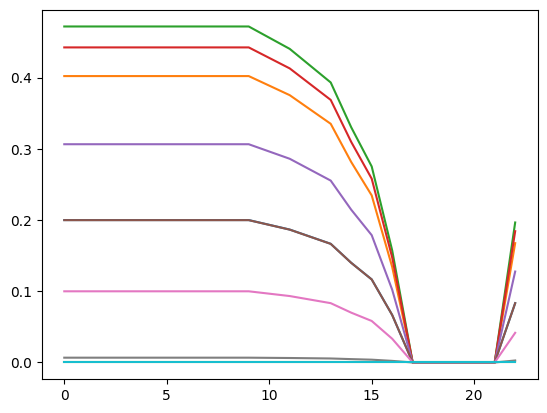

In [ ]:
# Base model (section 4.1)
def f1(Mw, R_rup):
    # Just clip c4_magnitud instead of if/else
    c4_mag = jnp.clip(c4 - (c4 - 1) * (5 - Mw), min = c4, max = 1)
    R = (R_rup ** 2 + c4_mag ** 2) ** (1/2)

    base = a[1] + (a[2] + a[3] * (Mw - M[1])) * jnp.log(R) + a[17] * R_rup

    cond = (Mw <= M[2]).astype(int) + (Mw <= M[1]).astype(int)
    
    a_MM = lax.select_n(cond, a[5] * (Mw - M[1]), a[4] * (Mw - M[1]), a[6] * (Mw - M[2]))
    a_MM2 = lax.select(Mw <= M[2], a[7] * (8.5 - M[2]) ** 2, a[8] * (8.5 - Mw) ** 2)
    a_MM_min = lax.select(Mw <= M[2], a[4] * (M[2] - M[1]) + a[8] * (8.5 - M[2]) ** 2, jnp.zeros_like(T))
    
    gm = base + a_MM + a_MM2 + a_MM_min
    
    return gm

# SOF (section 4.2)
#   Combining f7, f8 into one fn
def f7_8(Mw, SOF):
    # Just double-select a instead of two separate functions,
    #   many of whose branches return 0s
    a_SOF = lax.select(SOF > 0, a[11], a[12])
    a_SOF = lax.select(jnp.abs(SOF) > 0.5, a_SOF, a[0]) 
    # Just clip instead of if/elseif/else
    return a_SOF * jnp.clip(Mw - 4, min = 0, max = 1)

# Site response (4.3)
def f5(SA_rock, vs30):
    # Straightforward
    vs30_arr = jnp.full_like(v1, vs30)
    vs30_star = jnp.clip(vs30_arr, max = v1)

    site = (a[10] + b * n) * jnp.log(vs30_star / v_lin)
    site2 = site - \
            b * jnp.log(SA_rock + c) + \
            b * jnp.log(SA_rock + c * (vs30_star / v_lin) ** n)
    
    return lax.select(v_lin >= vs30, site2, site)

# Hanging wall (4.4)
    # Only calculate if HW_flag is 1
def f4(Mw, dip, width, 
       R_x, R_jb, R_y0, 
       z_tor):
    # Clip insetad of if/else
    HW_taper1 = jnp.clip((90 - dip) / 45, max = 60 / 45)

    # Once again, clip instead of if/else
    HW_taper2_max = 1 + 0.2 * (Mw - 6.5)
    HW_taper2_main = HW_taper2_max - 0.8 * (Mw - 6.5) ** 2
    HW_taper2 = jnp.clip(HW_taper2_main, min = 0, max = HW_taper2_max)

    # Ugh...
    h1, h2, h3 = 0.25, 1.5, -0.75
    R1 = width * jnp.cos(dip * jnp.pi / 180)
    R2 = 3 * R1
    HW_taper3_main = 1 - (R_x / R1) / (R2 - R1)
    HW_taper3_min = h1 + h2 * (R_x / R1) + h3 * (R_x / R1) ** 2
    cond = (R_x < R2).astype(int) + (R_x <= R1).astype(int)
    HW_taper3 = lax.select_n(cond, 0., HW_taper3_main, HW_taper3_min)

    HW_taper4 = jnp.clip(1 - (z_tor ** 2) / 100, min = 0)

    # Last one!...
    R_y1 = R_x * jnp.tan(20 * jnp.pi / 180)
    HW_taper5_R_y0 = jnp.clip(1 - (R_y0 - R_y1) / 5, min = 0, max = 1)
    HW_taper5_else = jnp.clip(1 - R_jb / 30, min = 0, max = 1)
    HW_taper5 = lax.select(R_y0 >= 0, HW_taper5_R_y0, HW_taper5_else)

    return a[13] * HW_taper1 * HW_taper2 * HW_taper3 * HW_taper4 * HW_taper5

# Top of rupture model (section 4.5)
def f6(z_tor):
    return a[15] * jnp.clip(z_tor / 20, max = 1)

# Soil depth model (section 4.6; only changes anything if z1p0 < 0)
def f10(vs30, 
        z1p0, 
        region):
    z1p0_ref_10 = jnp.exp(-5.23 / 2 * jnp.log((vs30 ** 2 + 412 ** 2) / (1360 ** 2 + 412 ** 2))) / 1000
    z1p0_ref_else = jnp.exp(-7.67 / 4 * jnp.log((vs30 ** 2 + 610 ** 2) / (1360 ** 2 + 610 ** 2))) / 1000
    z1p0_ref = lax.select(region == 10, z1p0_ref_10, z1p0_ref_else)
    ret = lax.select(z1p0 < 0., z1p0_ref, z1p0)
    return jnp.full_like(T, ret)

# Regional model (4.8)
def regional(R_rup, 
             vs30, 
             region):
    TW, CN, JP = 3, 9, 10
    val_dict = dict(zip([TW, CN, JP], jnp.arange(1, 4)))
    def f_TW():
        vs30_arr = jnp.full_like(v1, vs30)
        vs30_star = jnp.clip(vs30_arr, min = v1)
        f12 = a[31] * jnp.log(vs30_star / v_lin)
        delta_TW = f12 + a[25] * R_rup
        return delta_TW

    def f_CN():
        delta_CN = a[28] * R_rup
        return delta_CN

    def f_JP():
        JP_vs_mid = jnp.array([150, 250, 350, 450, 600, 850, 1150, 2000])
        a_JP = jnp.concatenate([a[36:43], a[42:43]]).T
        f13 = jax.vmap(Partial(jnp.interp, x = vs30, xp = JP_vs_mid))(fp = a_JP)
        delta_JP = f13 + a[29] * R_rup
        return delta_JP
    
    def f_else():
        return jnp.zeros_like(T, dtype = jnp.float32)

    delta = lax.switch(val_dict.get(region, 0), [f_else, f_TW, f_CN, f_JP])
    
    return delta

# Sigma
def f_std(Mw, 
         R_rup, 
         vs30, vs30_flag, 
         region, SA1180):
    
    s1 = lax.select(vs30_flag, s[1], s_est[1])
    s2 = lax.select(vs30_flag, s[2], s_est[2])
    def phi_al_else():
        phi_al = s1 + (s2 - s1) / 2 * (Mw - 4)
        phi_al = jnp.clip(phi_al, min = s1, max = s2)
        return phi_al
    
    def phi_al_JP():
        phi_al = s[5] + (s[6] - s[5]) / 50 * (R_rup - 30)
        phi_al = jnp.clip(phi_al, min = s[5], max = s[6])
        return phi_al
    
    phi_al = lax.select(region == 10, phi_al_JP(), phi_al_else())

    tauB = s[3] + (s[4] - s[3]) / 2 * (Mw - 5)
    tauB = jnp.clip(tauB, min = s[3], max = s[4])

    phi_amp = 0.4
    phiB = (phi_al ** 2 - phi_amp ** 2) ** (1 / 2)

    dAmp_dSA1180 = b * SA1180 * (-1 / (SA1180 + c) + 1 / (SA1180 + c * (vs30 / v_lin) ** n))
    dAmp_dSA1180 = dAmp_dSA1180.at[v_lin <= vs30].set(0)

    phi = (phiB ** 2 * (1 + dAmp_dSA1180) ** 2 + phi_amp ** 2) ** (1 / 2)
    tau = tauB * (1 + dAmp_dSA1180)

    sig = (phi ** 2 + tau ** 2) ** (1 / 2)
    return sig

# lnSA
def f_lnSA(Mw, width, dip, 
        R_jb, R_rup, R_x, R_y0, 
        vs30, 
        z1p0, z_tor, SA_rock,
        SOF, HW_flag, region):
    f_filler = lambda *args: jnp.zeros_like(T)

    return (
           f1(Mw, R_rup) + 
           f7_8(Mw, SOF) + 
           f5(SA_rock, vs30) + 
           lax.cond(HW_flag, f4, f_filler, Mw, dip, width, R_x, R_jb, R_y0, z_tor) + 
           f6(z_tor) +
           f10(vs30, z1p0, region) + 
           regional(R_rup, vs30, region)
        )

# Full Model
def ASK14(scn: gm_scenario):
    Mw, dip, rake, width = scn.Mw, scn.dip, scn.rake, scn.width
    R_jb, R_rup, R_x, R_y0 = scn.R_jb, scn.R_rup, scn.R_x, scn.R_y0
    vs30, vs30_flag = scn.vs30, scn.vs30_flag
    z1p0, z2p5, z_tor = scn.z1p0, scn.z2p5, scn.z_tor
    SOF, HW_flag, region = scn.SOF, scn.HW_flag, scn.region

    lnSA1180 = f_lnSA(Mw, width, dip, 
                      R_jb, R_rup, R_x, R_y0,
                      1180,
                      -1., z_tor, 
                      0., SOF, HW_flag, region)
    
    SA1180 = jnp.exp(lnSA1180)

    lnSA = f_lnSA(Mw, width, dip, 
                  R_jb, R_rup, R_x, R_y0, 
                  vs30, 
                  z1p0, z_tor, 
                  SA1180, SOF, HW_flag, region)
    
    std = f_std(Mw, R_rup, vs30, vs30_flag, region, SA1180)
    return T, lnSA, std



"""
true_ask14:
- Mandatory:
    - dip (float)
    - dist_jb (float)
    - dist_rup (float)
    - dist_x (float)
    - mag (float)
    - mechanism (str, "SS", "NS", "RS")
    - v_s30
- Optional:
    - depth_1_0 (float)
    - depth_2_5 (float)
    - depth_tor (float)
    - depth_bor (float)
    - dist_y0 (float)
    - on_hanging_wall (bool, None = false)
    - region (str, 'global', 'cali', 'china', 'italy', 'japan', 'taiwan')
    - vs_source (str, 'measured', 'inferred')
    - width (float, none = model average)
"""